In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (14, 5)
plt.style.use('seaborn-v0_8-whitegrid')

print("OK")

OK


In [5]:
from pathlib import Path
import pandas as pd

# Chemin absolu — indépendant du répertoire de travail du kernel
DATA_PATH = Path("/workspaces/industrial-ai-predictive-maintenance/data/raw/SKAB/data")

print(f"DATA_PATH existe : {DATA_PATH.exists()}")

dfs = []
for folder in ["valve1", "valve2", "other"]:
    folder_path = DATA_PATH / folder
    files = sorted(folder_path.glob("*.csv"))
    print(f"{folder} : {len(files)} fichiers")
    for f in files:
        try:
            df = pd.read_csv(f, sep=";", index_col="datetime", parse_dates=True)
            df["source"] = folder
            df["file"] = f.name
            dfs.append(df)
        except Exception as e:
            print(f"  Skipped {f.name}: {e}")

print(f"\nDataframes chargés : {len(dfs)}")

df_all = pd.concat(dfs, join="outer").sort_index()

exclude = ["anomaly", "changepoint", "source", "file"]
sensor_cols = [c for c in df_all.columns if c not in exclude]

print(f"Shape total  : {df_all.shape}")
print(f"Période      : {df_all.index.min()} → {df_all.index.max()}")
print(f"Sources      : {df_all['source'].value_counts().to_dict()}")
print(f"Anomalies    : {int(df_all['anomaly'].sum())} pts ({df_all['anomaly'].mean()*100:.1f}%)")
print(f"Capteurs     : {sensor_cols}")

DATA_PATH existe : True
valve1 : 16 fichiers
valve2 : 4 fichiers
other : 14 fichiers

Dataframes chargés : 34
Shape total  : (37401, 12)
Période      : 2020-02-08 16:06:48 → 2020-03-09 17:14:09
Sources      : {'valve1': 18160, 'other': 14929, 'valve2': 4312}
Anomalies    : 13067 pts (34.9%)
Capteurs     : ['Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 'Pressure', 'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS']


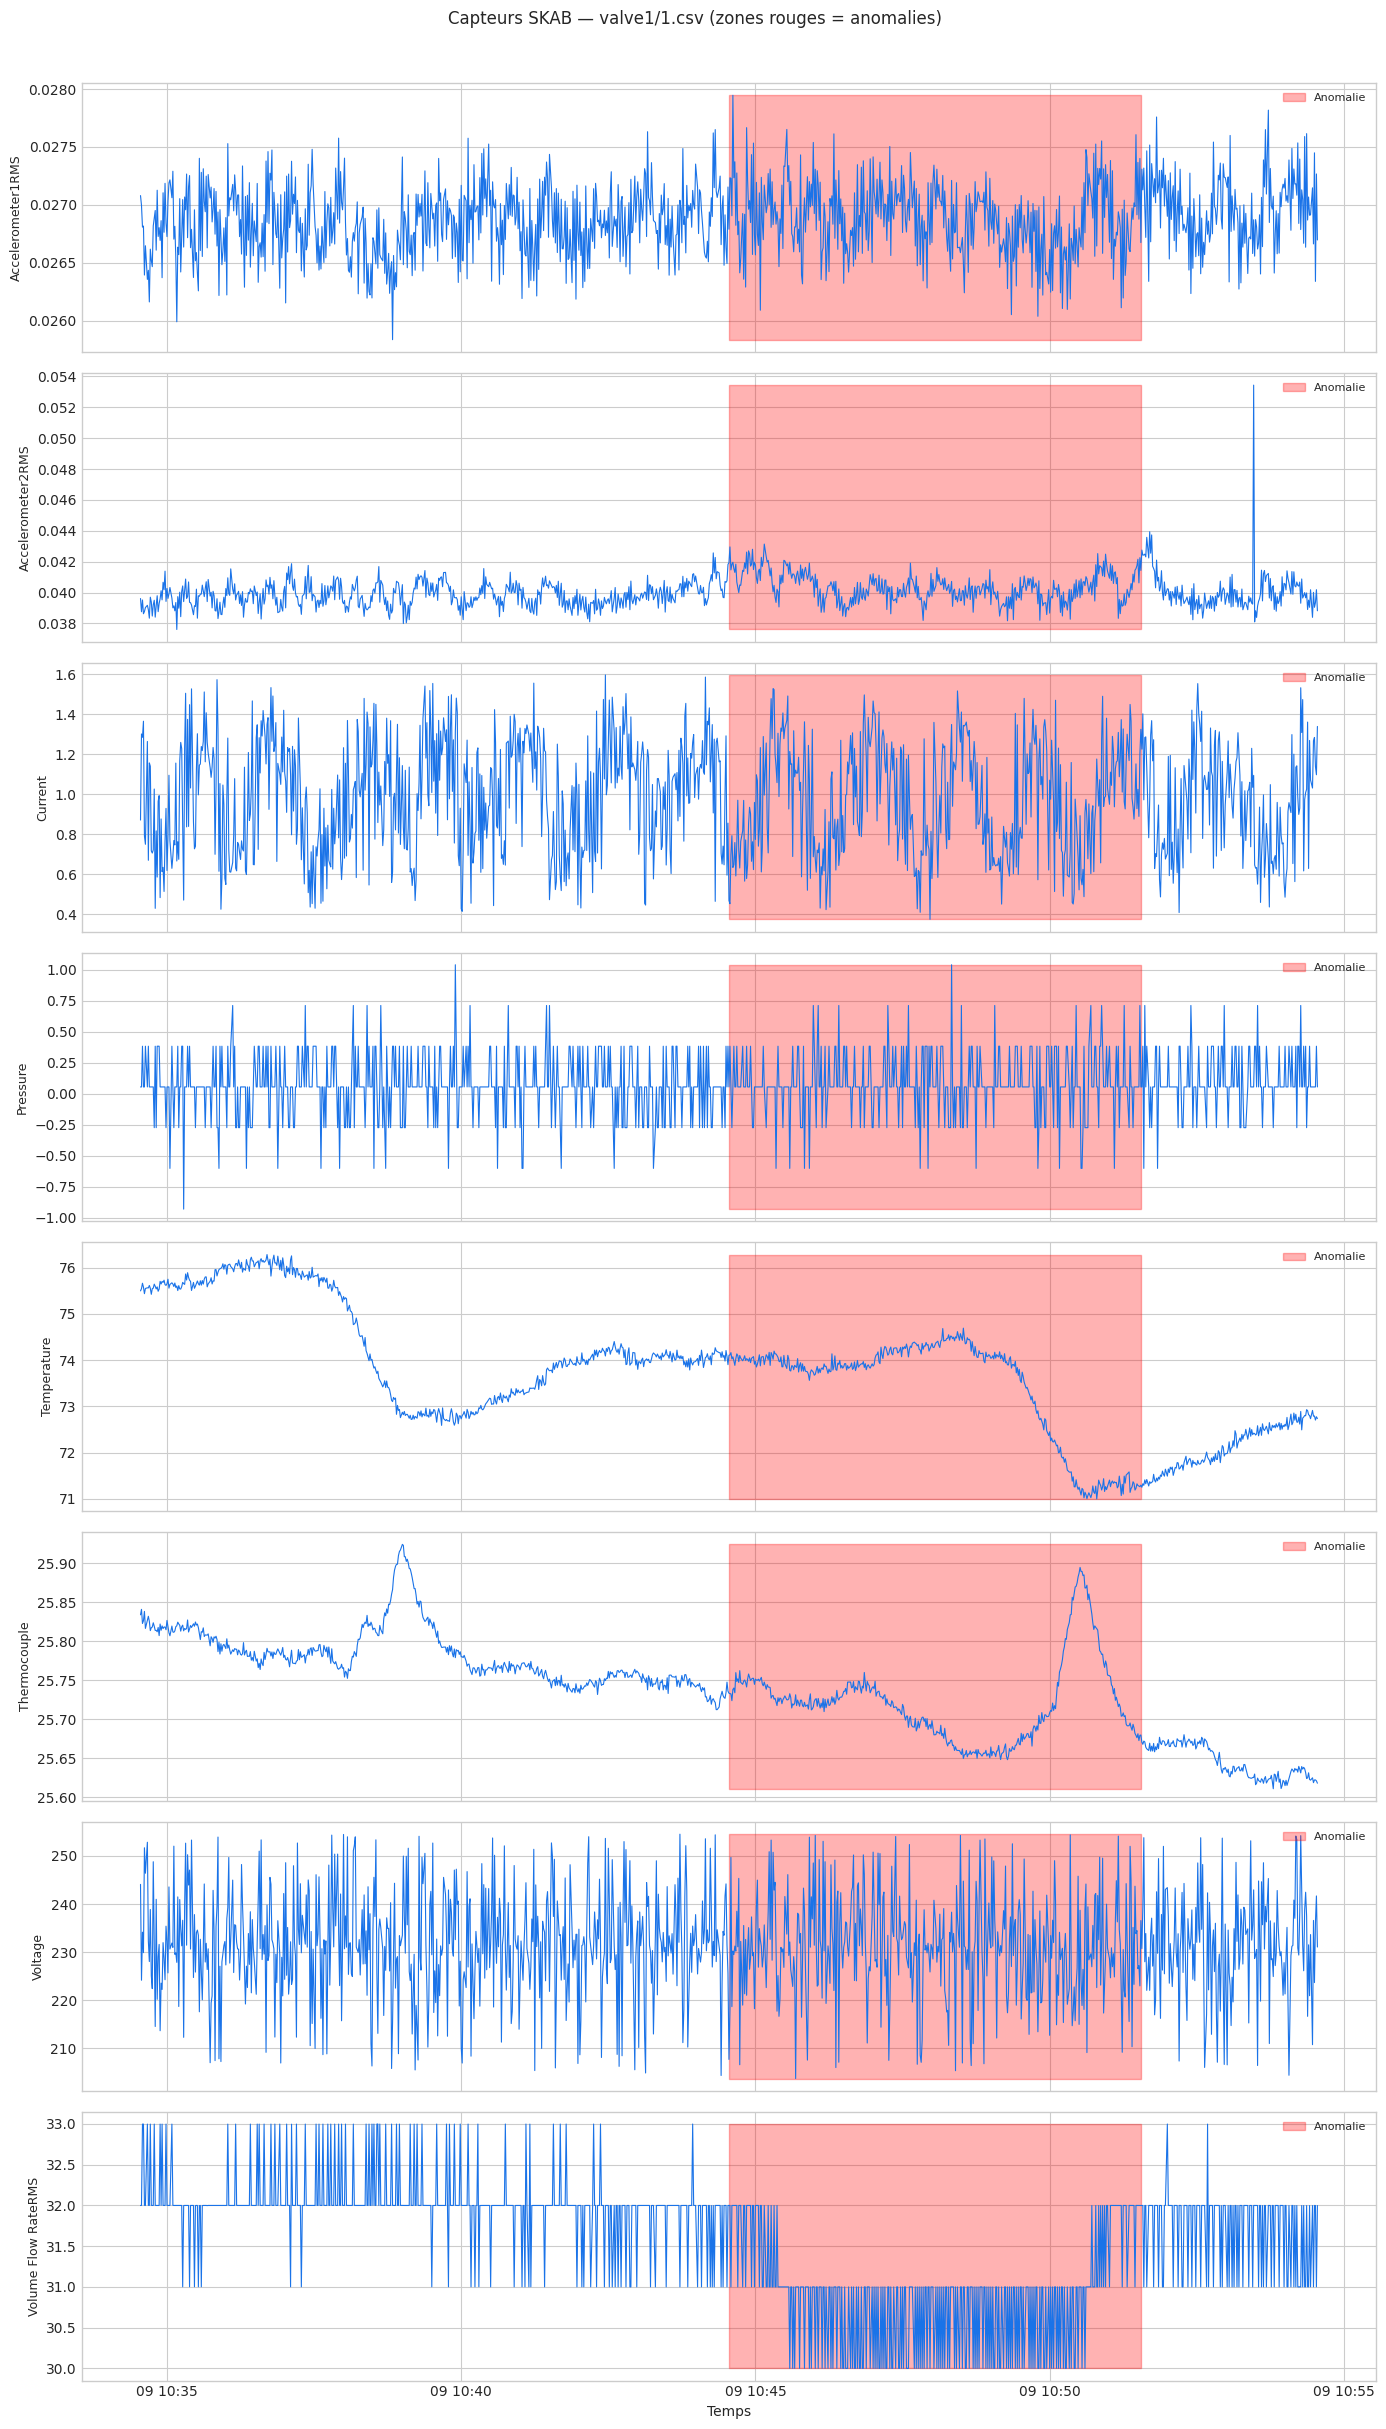

OK


In [6]:
df_sample = pd.read_csv(
    "/workspaces/industrial-ai-predictive-maintenance/data/raw/SKAB/data/valve1/1.csv",
    sep=";", index_col="datetime", parse_dates=True
)

sensor_cols_sample = [c for c in df_sample.columns if c not in ["anomaly","changepoint"]]

fig, axes = plt.subplots(len(sensor_cols_sample), 1,
                          figsize=(14, 3*len(sensor_cols_sample)),
                          sharex=True)

for ax, col in zip(axes, sensor_cols_sample):
    ax.plot(df_sample.index, df_sample[col], linewidth=0.8, color="#1a73e8")
    anomaly_mask = df_sample["anomaly"] == 1
    ax.fill_between(
        df_sample.index,
        df_sample[col].min(),
        df_sample[col].max(),
        where=anomaly_mask,
        alpha=0.3, color="red", label="Anomalie"
    )
    ax.set_ylabel(col, fontsize=9)
    ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Temps")
fig.suptitle("Capteurs SKAB — valve1/1.csv (zones rouges = anomalies)", y=1.01)
plt.tight_layout()
plt.savefig("/workspaces/industrial-ai-predictive-maintenance/notebooks/skab_sensors_overview.png",
            dpi=120, bbox_inches="tight")
plt.show()
print("OK")

In [8]:
df_normal  = df_all[df_all["anomaly"] == 0][sensor_cols]
df_anomaly = df_all[df_all["anomaly"] == 1][sensor_cols]

comparison = pd.DataFrame({
    "mean_normal"  : df_normal.mean().round(4),
    "mean_anomaly" : df_anomaly.mean().round(4),
    "std_normal"   : df_normal.std().round(4),
    "std_anomaly"  : df_anomaly.std().round(4),
    "delta_%"      : ((df_anomaly.mean() - df_normal.mean())
                      / df_normal.mean() * 100).round(1)
})

# Trier par delta absolu — les capteurs les plus discriminants en premier
comparison["abs_delta"] = comparison["delta_%"].abs()
comparison = comparison.sort_values("abs_delta", ascending=False).drop(columns="abs_delta")

print(" Capteurs classés par sensibilité aux anomalies \n")
print(comparison.to_string())

 Capteurs classés par sensibilité aux anomalies 

                     mean_normal  mean_anomaly  std_normal  std_anomaly  delta_%
Accelerometer1RMS         0.0931        0.1366      0.0912       0.1858     46.6
Accelerometer2RMS         0.1196        0.1674      0.1055       0.2067     40.0
Pressure                  0.0724        0.0694      0.2610       0.2599     -4.1
Volume Flow RateRMS      63.9563       61.3087     42.1607      43.1298     -4.1
Current                   1.4608        1.4711      0.7394       0.7442      0.7
Thermocouple             26.0106       26.1363      2.5393       2.8272      0.5
Temperature              76.8923       76.6105      8.8885       8.7222     -0.4
Voltage                 229.8670      229.7445     10.9446      10.9094     -0.1


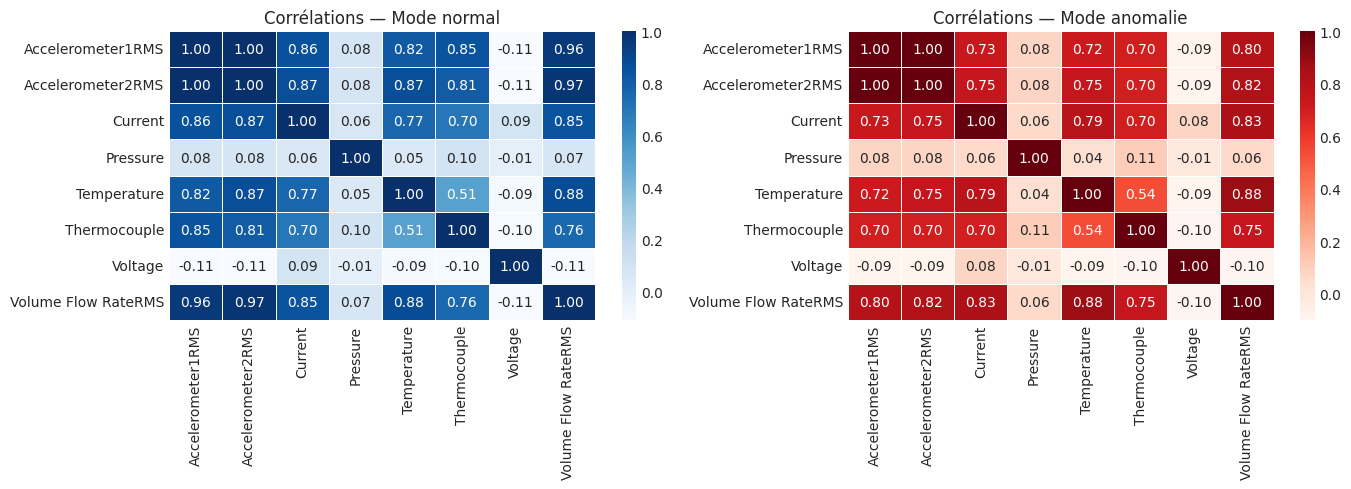

OK


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(df_normal.corr().round(2), annot=True, fmt=".2f",
            cmap="Blues", ax=ax1, linewidths=0.5)
ax1.set_title("Corrélations — Mode normal")

sns.heatmap(df_anomaly.corr().round(2), annot=True, fmt=".2f",
            cmap="Reds", ax=ax2, linewidths=0.5)
ax2.set_title("Corrélations — Mode anomalie")

plt.tight_layout()
plt.savefig("/workspaces/industrial-ai-predictive-maintenance/notebooks/skab_correlations.png",
            dpi=120, bbox_inches="tight")
plt.show()
print("OK")